In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

import torch.optim as optim

In [2]:
# Download training data from open datasets.
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

In [3]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [4]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [5]:
# Define model
class NeuralNetwork_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        output = self.linear_relu_stack(x)
        return output

model_MLP = NeuralNetwork_MLP().to(device)
print(model_MLP)

NeuralNetwork_MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [6]:
# Архитектура сверточной нейросети
class NeuralNetwork_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
                
        self.linear_stack_1 = nn.Sequential(
                    nn.Conv2d(1, 32, 3, 1),
                    nn.ReLU(),
                    nn.Conv2d(32, 64, 3, 1),
                    nn.ReLU(),
                    nn.MaxPool2d(kernel_size=2),
                    nn.Dropout(0.25)
                )
        
        self.linear_stack_2 = nn.Sequential(
                    nn.Linear(9216, 128),
                    nn.ReLU(),
                    nn.Dropout(0.5),
                    nn.Linear(128, 10),
                )
        
    def forward(self, x):
        x = self.linear_stack_1(x)
        x = self.flatten(x)
        output = self.linear_stack_2(x)
        return output

model_CNN = NeuralNetwork_CNN().to(device)
print(model_CNN)

NeuralNetwork_CNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_stack_1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Dropout(p=0.25, inplace=False)
  )
  (linear_stack_2): Sequential(
    (0): Linear(in_features=9216, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [7]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
    
        # Compute prediction error
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [8]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model.eval()
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            pred = model(X)
            test_loss += loss_fn(pred, y).item()

            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size

    print(f"Test Error: \n Accuracy: {100*correct:.1f}%, Avg loss: {test_loss:.6f}\n")

In [9]:
# Loss и optimizer для MLP
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_MLP.parameters(), lr=1e-3)

In [10]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model_MLP, loss_fn, optimizer)
    test(test_dataloader, model_MLP, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.299405  [   64/60000]
loss: 0.248452  [ 6464/60000]
loss: 0.173868  [12864/60000]
loss: 0.239278  [19264/60000]
loss: 0.146858  [25664/60000]
loss: 0.362529  [32064/60000]
loss: 0.126344  [38464/60000]
loss: 0.249025  [44864/60000]
loss: 0.312959  [51264/60000]
loss: 0.173135  [57664/60000]
Test Error: 
 Accuracy: 95.4%, Avg loss: 0.141660

Epoch 2
-------------------------------
loss: 0.094154  [   64/60000]
loss: 0.126900  [ 6464/60000]
loss: 0.072110  [12864/60000]
loss: 0.126397  [19264/60000]
loss: 0.036299  [25664/60000]
loss: 0.111729  [32064/60000]
loss: 0.069513  [38464/60000]
loss: 0.130776  [44864/60000]
loss: 0.095376  [51264/60000]
loss: 0.095761  [57664/60000]
Test Error: 
 Accuracy: 97.3%, Avg loss: 0.090536

Epoch 3
-------------------------------
loss: 0.057655  [   64/60000]
loss: 0.057215  [ 6464/60000]
loss: 0.047504  [12864/60000]
loss: 0.123471  [19264/60000]
loss: 0.030543  [25664/60000]
loss: 0.051137  [32064/60000

In [11]:
torch.save(model_MLP.state_dict(), "model_MLP.pth")
print("Saved PyTorch Model State to model_MLP.pth")

Saved PyTorch Model State to model_MLP.pth


In [12]:
# Loss и optimizer для CNN
loss_fn_CNN = nn.CrossEntropyLoss()
optimizer_CNN = torch.optim.Adam(model_CNN.parameters(), lr=1e-3)

In [13]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model_CNN, loss_fn_CNN, optimizer_CNN)
    test(test_dataloader, model_CNN, loss_fn_CNN)
print("Done!")

Epoch 1
-------------------------------
loss: 2.307001  [   64/60000]
loss: 0.388157  [ 6464/60000]
loss: 0.152899  [12864/60000]
loss: 0.199475  [19264/60000]
loss: 0.086262  [25664/60000]
loss: 0.246810  [32064/60000]
loss: 0.115199  [38464/60000]
loss: 0.280186  [44864/60000]
loss: 0.181765  [51264/60000]
loss: 0.094959  [57664/60000]
Test Error: 
 Accuracy: 98.2%, Avg loss: 0.059974

Epoch 2
-------------------------------
loss: 0.089815  [   64/60000]
loss: 0.084548  [ 6464/60000]
loss: 0.115935  [12864/60000]
loss: 0.084465  [19264/60000]
loss: 0.092290  [25664/60000]
loss: 0.118261  [32064/60000]
loss: 0.094240  [38464/60000]
loss: 0.214864  [44864/60000]
loss: 0.144635  [51264/60000]
loss: 0.077307  [57664/60000]
Test Error: 
 Accuracy: 98.6%, Avg loss: 0.044263

Epoch 3
-------------------------------
loss: 0.113489  [   64/60000]
loss: 0.104923  [ 6464/60000]
loss: 0.056913  [12864/60000]
loss: 0.184617  [19264/60000]
loss: 0.123869  [25664/60000]
loss: 0.219537  [32064/60000

In [14]:
torch.save(model_CNN.state_dict(), "model_CNN.pth")
print("Saved PyTorch Model State to model_CNN.pth")

Saved PyTorch Model State to model_CNN.pth


In [15]:
model_MLPload = NeuralNetwork_MLP().to(device)
model_MLPload.load_state_dict(torch.load("model_MLP.pth", weights_only=True))

model_CNNload = NeuralNetwork_CNN().to(device)
model_CNNload.load_state_dict(torch.load("model_CNN.pth", weights_only=True))

<All keys matched successfully>

In [16]:
model_CNNload.eval()
model_MLPload.eval()

x, y = test_data[0]

x_CNN = x.unsqueeze(0).to(device)
x_MLP = x.unsqueeze(0).to(device)

with torch.no_grad():
    # CNN
    pred_CNN = model_CNNload(x_CNN)
    predicted_CNN = pred_CNN.argmax(1).item()

    # MLP
    pred_MLP = model_MLPload(x_MLP)
    predicted_MLP = pred_MLP.argmax(1).item()

print("CNN:", predicted_CNN, "Actual:", y)
print("MLP:", predicted_MLP, "Actual:", y)

CNN: 7 Actual: 7
MLP: 7 Actual: 7


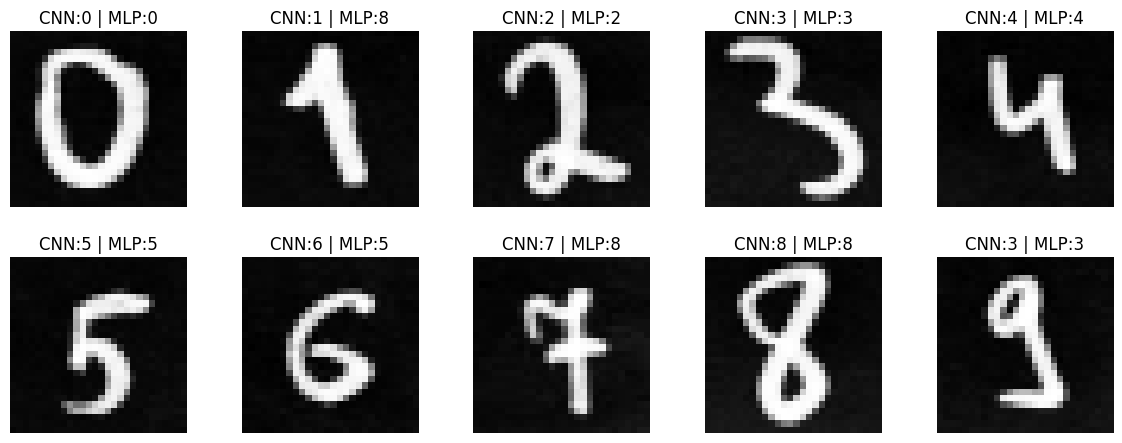

In [18]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import os
import torch

# transform
transform = transforms.Compose([
    transforms.Grayscale(),
    #transforms.Resize((28, 28)),
    transforms.ToTensor(),
    #transforms.Normalize((0.5,), (0.5,))
])

folder = "pic"

model_CNN.eval()
model_MLP.eval()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

with torch.no_grad():
    for i in range(10):
        path = os.path.join(folder, f"test_pic{i}.png")
        
        img = Image.open(path)
        x = transform(img)

        # inputs
        x_cnn = x.unsqueeze(0).to(device)
        x_mlp = x.view(1, -1).to(device)

        # predictions
        pred_cnn = model_CNN(x_cnn).argmax(1).item()
        pred_mlp = model_MLP(x_mlp).argmax(1).item()

        # plot
        ax = axes[i // 5, i % 5]
        ax.imshow(x.squeeze().cpu(), cmap="gray")
        ax.set_title(f"CNN:{pred_cnn} | MLP:{pred_mlp}")
        ax.axis("off")

plt.tight_layout(pad=3.0)
plt.show()

Несмотря на различия между моими изображениями и данными MNIST, обе модели смогли их классифицировать. Однако CNN показала значительно более хорошие  результаты по сравнению с MLP.

Возможные улучшения включают доработку preprocessing (центрирование, бинаризация, нормализация) и изменение архитектуры MLP (увеличение глубины, регуляризация), однако для задач классификации изображений CNN в целом является более подходящей моделью.